# Agent lambda preference and role-specific ranking

This notebook keeps the analysis minimal:

1. Read the survey CSV.
2. Convert each participant's agent ranking into long format.
3. Classify each participant as **prefers high lambda** or **prefers low lambda** using the sign of their overall Spearman correlation between agent lambda and rank.
4. For each role separately, test whether their rank order follows the expected lambda direction.

Rank interpretation: **1 = best/preferred**, **6 = worst**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

CSV_PATH = Path("survey_phase.csv")
if not CSV_PATH.exists():
    CSV_PATH = Path("/mnt/data/survey_phase(1).csv")

AGENT_INFO = {
    "Tom":   {"case": 1, "role": "security", "level": "high", "lambda": 0.00},
    "Jerry": {"case": 2, "role": "forager",  "level": "high", "lambda": 0.00},
    "Cindy": {"case": 3, "role": "security", "level": "med",  "lambda": -0.75},
    "Frank": {"case": 4, "role": "forager",  "level": "med",  "lambda": 0.40},
    "Alice": {"case": 5, "role": "security", "level": "low",  "lambda": 0.40},
    "Grace": {"case": 6, "role": "forager",  "level": "low",  "lambda": -0.75},
}

In [2]:
df = pd.read_csv(CSV_PATH)

rank_cols = [f"final_rank_{i}_agent" for i in range(1, 7)]
agent_df = (
    pd.DataFrame.from_dict(AGENT_INFO, orient="index")
    .rename_axis("agent")
    .reset_index()
)

long = (
    df.melt(
        id_vars=["participant_id"],
        value_vars=rank_cols,
        var_name="rank_col",
        value_name="agent"
    )
    .dropna(subset=["agent"])
)

long["rank"] = long["rank_col"].str.extract(r"(\d+)").astype(int)
long = long.merge(agent_df, on="agent", how="left")
long = long.dropna(subset=["lambda", "role"])

long.head()

,participant_id,rank_col,agent,rank,case,role,level,lambda
0,Bill,final_rank_1_agent,Grace,1,6,forager,low,-0.75
1,Cici Zhang,final_rank_1_agent,Cindy,1,3,security,med,-0.75
2,Dhriti,final_rank_1_agent,Tom,1,1,security,high,0.00
3,Nishka,final_rank_1_agent,Tom,1,1,security,high,0.00
4,Rumi,final_rank_1_agent,Tom,1,1,security,high,0.00


## Participant-level lambda preference

Because smaller rank numbers mean stronger preference:

- **Spearman r < 0** means higher-lambda agents tend to receive better ranks.
- **Spearman r > 0** means lower-lambda agents tend to receive better ranks.


In [3]:
participant_pref = (
    long.groupby("participant_id")[["lambda", "rank"]]
    .apply(lambda g: g["lambda"].corr(g["rank"], method="spearman"))
    .rename("overall_spearman")
    .reset_index()
)

participant_pref["preference_group"] = np.select(
    [
        participant_pref["overall_spearman"] < 0,
        participant_pref["overall_spearman"] > 0,
    ],
    [
        "prefers high lambda",
        "prefers low lambda",
    ],
    default="no clear direction"
)

long = long.merge(participant_pref, on="participant_id", how="left")

participant_pref

,participant_id,overall_spearman,preference_group
0,Bill,0.956183,prefers low lambda
1,Cici Zhang,0.478091,prefers low lambda
2,Dhriti,-0.239046,prefers high lambda
3,Nishka,-0.478091,prefers high lambda
4,Rumi,0.358569,prefers low lambda
5,Trevor,-0.478091,prefers high lambda
6,Yingru Guo,-0.478091,prefers high lambda
7,aidan,0.239046,prefers low lambda
8,carol,-0.717137,prefers high lambda


## Role-specific alignment

For each participant and role:

- If they **prefer high lambda**, the expected within-role order is `0.40 → 0.00 → -0.75`.
- If they **prefer low lambda**, the expected within-role order is `-0.75 → 0.00 → 0.40`.

`alignment_score = 1` means the participant's ranking exactly follows their expected lambda direction within that role.


In [4]:
role_alignment = (
    long.groupby(["participant_id", "preference_group", "role"])[["lambda", "rank"]]
    .apply(lambda g: g["lambda"].corr(g["rank"], method="spearman"))
    .rename("role_spearman")
    .reset_index()
)

role_alignment["alignment_score"] = np.where(
    role_alignment["preference_group"].eq("prefers high lambda"),
    -role_alignment["role_spearman"],
    np.where(
        role_alignment["preference_group"].eq("prefers low lambda"),
        role_alignment["role_spearman"],
        np.nan
    )
)

role_alignment["exact_expected_order"] = np.isclose(role_alignment["alignment_score"], 1)

display(role_alignment)

summary = (
    role_alignment
    .groupby(["preference_group", "role"], as_index=False)
    .agg(
        n=("participant_id", "nunique"),
        mean_alignment=("alignment_score", "mean"),
        exact_order_rate=("exact_expected_order", "mean"),
    )
)

summary

,participant_id,preference_group,role,role_spearman,alignment_score,exact_expected_order
0,Bill,prefers low lambda,forager,1.0,1.0,True
1,Bill,prefers low lambda,security,1.0,1.0,True
2,Cici Zhang,prefers low lambda,forager,-0.5,-0.5,False
3,Cici Zhang,prefers low lambda,security,1.0,1.0,True
4,Dhriti,prefers high lambda,forager,0.5,-0.5,False
5,Dhriti,prefers high lambda,security,-0.5,0.5,False
6,Nishka,prefers high lambda,forager,-0.5,0.5,False
7,Nishka,prefers high lambda,security,-0.5,0.5,False
8,Rumi,prefers low lambda,forager,1.0,1.0,True
9,Rumi,prefers low lambda,security,0.5,0.5,False


,preference_group,role,n,mean_alignment,exact_order_rate
0,prefers high lambda,forager,5,0.400,0.20
1,prefers high lambda,security,5,0.400,0.20
2,prefers low lambda,forager,4,0.125,0.50
3,prefers low lambda,security,4,0.875,0.75


## Minimal role-specific plots

Each plot shows the mean rank at each lambda level, separately for participants who prefer high lambda vs. low lambda.

Lower values are better ranks, so the y-axis is inverted.


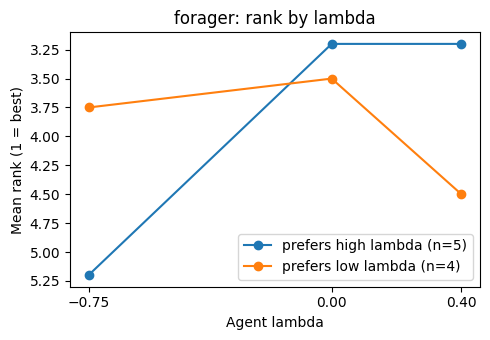

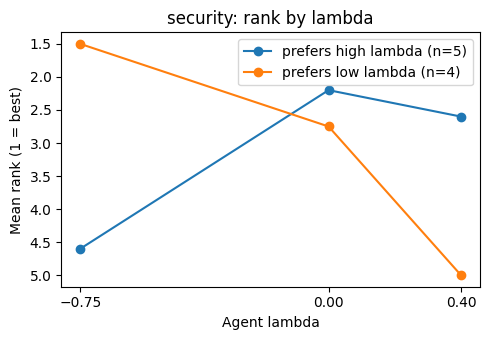

In [5]:
plot_data = (
    long.groupby(["role", "preference_group", "lambda"], as_index=False)
    .agg(mean_rank=("rank", "mean"))
)

group_n = (
    participant_pref.groupby("preference_group")["participant_id"]
    .nunique()
    .to_dict()
)

for role in ["forager", "security"]:
    g_role = plot_data[plot_data["role"].eq(role)]

    plt.figure(figsize=(5, 3.5))

    for group, g in g_role.groupby("preference_group"):
        g = g.sort_values("lambda")
        plt.plot(
            g["lambda"],
            g["mean_rank"],
            marker="o",
            label=f"{group} (n={group_n.get(group, 0)})"
        )

    plt.gca().invert_yaxis()
    plt.xticks(sorted(long["lambda"].unique()))
    plt.xlabel("Agent lambda")
    plt.ylabel("Mean rank (1 = best)")
    plt.title(f"{role}: rank by lambda")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Quick interpretation for the current sample

Use the tables and plots above:

- `preference_group` tells you whether each participant generally preferred high-lambda or low-lambda agents.
- `role_spearman` tells you the within-role lambda-rank pattern.
- `alignment_score` tells you whether that within-role pattern matches the participant's overall lambda preference.
- `exact_order_rate` is the proportion of participants in that group whose role-specific ranking perfectly follows the expected lambda direction.
